In [179]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
import os

In [180]:
load_dotenv()

True

In [181]:
model = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [182]:
class EvaluationSchema(BaseModel):
    feedback: str 
    score: int 

In [183]:
structured_model = model.with_structured_output(EvaluationSchema,method="json_mode")

In [184]:
essay = """Artificial Intelligence (AI) is transforming the world by making machines smarter and improving the way people live and work. India, being one of the fastest-growing economies and a global technology hub, plays an important role in the development and adoption of AI. With its large pool of skilled professionals, growing startup ecosystem, and government initiatives, India is becoming a significant contributor to the AI revolution.

One of the major strengths of India in AI is its strong IT industry. Indian technology companies and software engineers are actively working on AI-based solutions in areas such as healthcare, education, agriculture, finance, and cybersecurity. Companies are using AI to automate tasks, improve customer service through chatbots, and analyze large amounts of data for better decision-making.

The Government of India has also taken several steps to promote AI development. Initiatives such as the National AI Strategy and programs under Digital India encourage innovation, research, and skill development in AI technologies. The government aims to use AI for social good by improving healthcare services, smart farming, traffic management, and digital governance.

In the healthcare sector, AI is helping doctors detect diseases early and provide better treatment plans. In agriculture, AI-powered tools help farmers predict weather conditions, monitor crops, and increase productivity. Similarly, in education, AI-based platforms provide personalized learning experiences to students and make education more accessible.

India is also becoming a center for AI startups and innovation. Many startups are developing advanced technologies in machine learning, robotics, and automation. Educational institutions and universities are introducing AI courses to prepare students for future job opportunities in this field.

However, India also faces challenges in AI development, such as lack of advanced infrastructure, data privacy concerns, and the need for skilled talent in rural areas. To fully benefit from AI, India must focus on research, ethical AI practices, and inclusive growth.

In conclusion, India has a crucial role in the field of Artificial Intelligence. With strong government support, talented professionals, and increasing technological advancements, India has the potential to become a global leader in AI. By using AI responsibly and effectively, India can solve many social and economic challenges while contributing to technological progress worldwide."""

In [185]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10:\n\n{essay}"
result = structured_model.invoke(prompt)

print(result)


[10]


In [186]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [187]:
def safe_parse_output(output):
   

    # Case 1: [9.5]
    if isinstance(output, list):
        first = output[0]

        if isinstance(first, (int, float)):
            return {
                "feedback": "No feedback generated",
                "score": float(first)
            }

        if isinstance(first, dict):
            output = first

    # Case 2: plain float
    if isinstance(output, (int, float)):
        return {
            "feedback": "No feedback generated",
            "score": float(output)
        }

    # Case 3: dict with weird keys
    if isinstance(output, dict):

        feedback = (
            output.get("feedback")
            or output.get("Feedback")
            or output.get("Specific Feedback")
            or "No feedback generated"
        )

        score = (
            output.get("score")
            or output.get("Score")
            or output.get("Depth of Analysis")
            or 0
        )

        # list -> string
        if isinstance(feedback, list):
            feedback = "\n".join(feedback)

        return {
            "feedback": str(feedback),
            "score": float(score)
        }

    raise ValueError(f"Unexpected output: {output}")


def evaluate_language(state: UPSCState):
    prompt = f"""
    Evaluate the language quality of the following essay.

    Return feedback and score out of 10.

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)
    output = safe_parse_output(output)

    return {
        'language_feedback': output['feedback'],
        'individual_scores': [output['score']]
    }


def evaluate_analysis(state: UPSCState):
    prompt = f"""
    Evaluate the depth of analysis of the essay.

  Return feedback and score out of 10.

    {{
        "feedback": "your feedback",
        "score": 0-10
    }}

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)
    output = safe_parse_output(output)

    return {
        'analysis_feedback': output['feedback'],
        'individual_scores': [output['score']]
    }


def evaluate_thought(state: UPSCState):
    prompt = f"""
    Evaluate the clarity of thought in the following essay.

    Return feedback and score out of 10.

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)
    output = safe_parse_output(output)

    return {
        'clarity_feedback': output['feedback'],
        'individual_scores': [output['score']]
    }



def final_evaluation(state: UPSCState):
    # summary of feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback: {state["language_feedback"]}\n depth of analysis feedback: {state["analysis_feedback"]}\n clarity of thought feedback: {state["clarity_feedback"]}\n '
    overall_feedback = model.invoke(prompt).content
    # average calculation
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}


In [188]:
graph = StateGraph(UPSCState)

# nodes
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)

# edges
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_thought")

graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")

graph.add_edge("final_evaluation", END)

# compile and run
workflow = graph.compile()



In [189]:
initial_state = {
    'essay': essay
    }
workflow.invoke(initial_state)

{'essay': 'Artificial Intelligence (AI) is transforming the world by making machines smarter and improving the way people live and work. India, being one of the fastest-growing economies and a global technology hub, plays an important role in the development and adoption of AI. With its large pool of skilled professionals, growing startup ecosystem, and government initiatives, India is becoming a significant contributor to the AI revolution.\n\nOne of the major strengths of India in AI is its strong IT industry. Indian technology companies and software engineers are actively working on AI-based solutions in areas such as healthcare, education, agriculture, finance, and cybersecurity. Companies are using AI to automate tasks, improve customer service through chatbots, and analyze large amounts of data for better decision-making.\n\nThe Government of India has also taken several steps to promote AI development. Initiatives such as the National AI Strategy and programs under Digital India

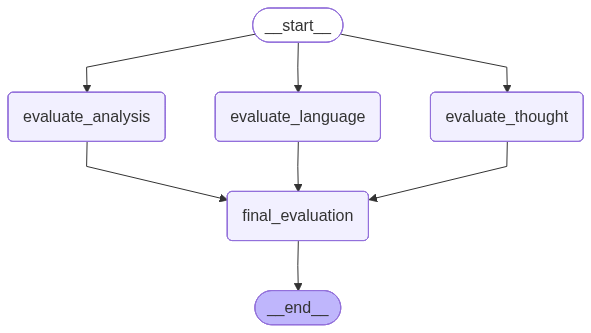

In [190]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())